# Single-Cell RNA-seq Analysis: QC, Normalization, Clustering & Marker Genes
### Using Seurat (R) with the 10x Mouse E18 Cortex Dataset

## What this notebook covers

| Module | Topic |
|--------|-------|
| 0 | Dataset background & data structure |
| 1 | Loading CellRanger output from first principles |
| 2 | QC metric calculation & pre-filter exploration |
| 3 | Initial (unfiltered) SCTransform + UMAP — look before you cut |
| 4 | Cell cycle scoring |
| 5 | Doublet detection with scDblFinder |
| 6 | Applying QC filters & removing uninformative features |
| 7 | Final SCTransform with confounder regression |
| 8 | Dimensionality reduction & clustering |
| 9 | Resolution selection with clustree |
| 10 | Marker gene identification & visualization |
| 11 | Cluster merging & manual annotation |

---


**Load the data and R packages into google colab**


*   You will need a google account (free)
*   Check your email for the shared google drive link, open it
*   Go to the 'Shared with me' tab in google drive
*   Click on more actions next to scRNAseq_course (three dots)
*   Organise >>> Add Shortcut >>> My Drive >>> Add
*   Now the data and pre-compiled R packages are accessible in your google drive

---
## Module 0 — Dataset: Mouse E18 Cortex (10x Genomics)

### Why this dataset?

We use the **10x Genomics E18 mouse brain cortex** dataset (~1,300 cells) throughout  
this course. It was generated from embryonic day 18 mouse cortex using the Chromium v3  
platform and is freely available from 10x Genomics.

### Biological context

At E18, the mouse cortex is in the final wave of neurogenesis. The major cell types are:

| Cell type | Markers | Division status |
|-----------|---------|-----------------|
| Radial glia (RG) | *Vim*, *Nes*, *Pax6* | Cycling |
| Intermediate progenitors (IPs) | *Eomes*, *Tbr2* | Cycling |
| Immature excitatory neurons | *Neurod2*, *Tbr1* | Post-mitotic |
| Mature excitatory neurons (upper layer) | *Cux1*, *Cux2* | Post-mitotic |
| Mature excitatory neurons (deep layer) | *Bcl11b*, *Fezf2* | Post-mitotic |
| Interneurons (migrating) | *Gad1*, *Gad2*, *Dlx2* | Post-mitotic |
| Endothelial / VLMC | *Cldn5*, *Col1a1* | Post-mitotic |

### Data structure from CellRanger

CellRanger outputs a directory containing three files that together encode a sparse matrix:

```
neuron_1k_v3_filtered_feature_bc_matrix/
├── barcodes.tsv.gz     # one cell barcode per line  (columns of the matrix)
├── features.tsv.gz     # gene ID + gene name        (rows of the matrix)
└── matrix.mtx.gz       # sparse matrix in Market Exchange Format
```

The matrix is stored in **Market Exchange (MEX) format** because scRNAseq count matrices  
are extremely sparse (~90% zeros). Storing every zero would waste gigabytes.  
A `.mtx` file only records the non-zero entries as `(row, column, value)` triplets.

---
## Module 1 — Setup & Loading CellRanger Output

1. What the files actually contain  
2. How a sparse matrix is constructed  
3. Why gene names need deduplication  
4. What `CreateSeuratObject()`'s `min.cells` and `min.features` arguments actually filter

In [ ]:
# Run this first and click the authentication link to point colab to the google drive (python)
# If this doesn't work first time restart the session (runtime (top left), restart session), or change runtime from R to python3 (dropdown next to RAM Disk (top right), change runtime type, change from R to python3)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Prevent timeout (python)
from IPython.display import display, Javascript
display(Javascript('''
function clickConnect() {
    document.querySelector("#top-toolbar > colab-connect-button")
            .shadowRoot.querySelector("#connect").click();
    setTimeout(clickConnect, 60000);
}
clickConnect();
'''))

In [ ]:
# Switch runtime to R (dropdown next to "RAM and Disk" top right, change runtime type, change from python3 to R)
# point R to the pre-compiled google drive R packages
lib_path <- "/content/drive/MyDrive/scRNAseq_course/Rlibs"
.libPaths(c(lib_path, .libPaths()))

In [ ]:
# ── 1.1  Libraries ────────────────────────────────────────────────────────────
# We load everything upfront so missing packages are caught immediately.
# Install any missing packages with: install.packages("pkg") or BiocManager::install("pkg") or conda if using a conda environment (reccomended)

library(Matrix)       # sparse matrix operations — the dgCMatrix class
library(Seurat)       # main scRNAseq analysis framework
library(ggplot2)      # all plotting
library(patchwork)    # combine ggplot panels with / and |
library(dplyr)        # data manipulation
library(scDblFinder)  # doublet detection

set.seed(42) # reproducibility by setting the random number seed
cat("Seurat version:", as.character(packageVersion("Seurat")), "\n")


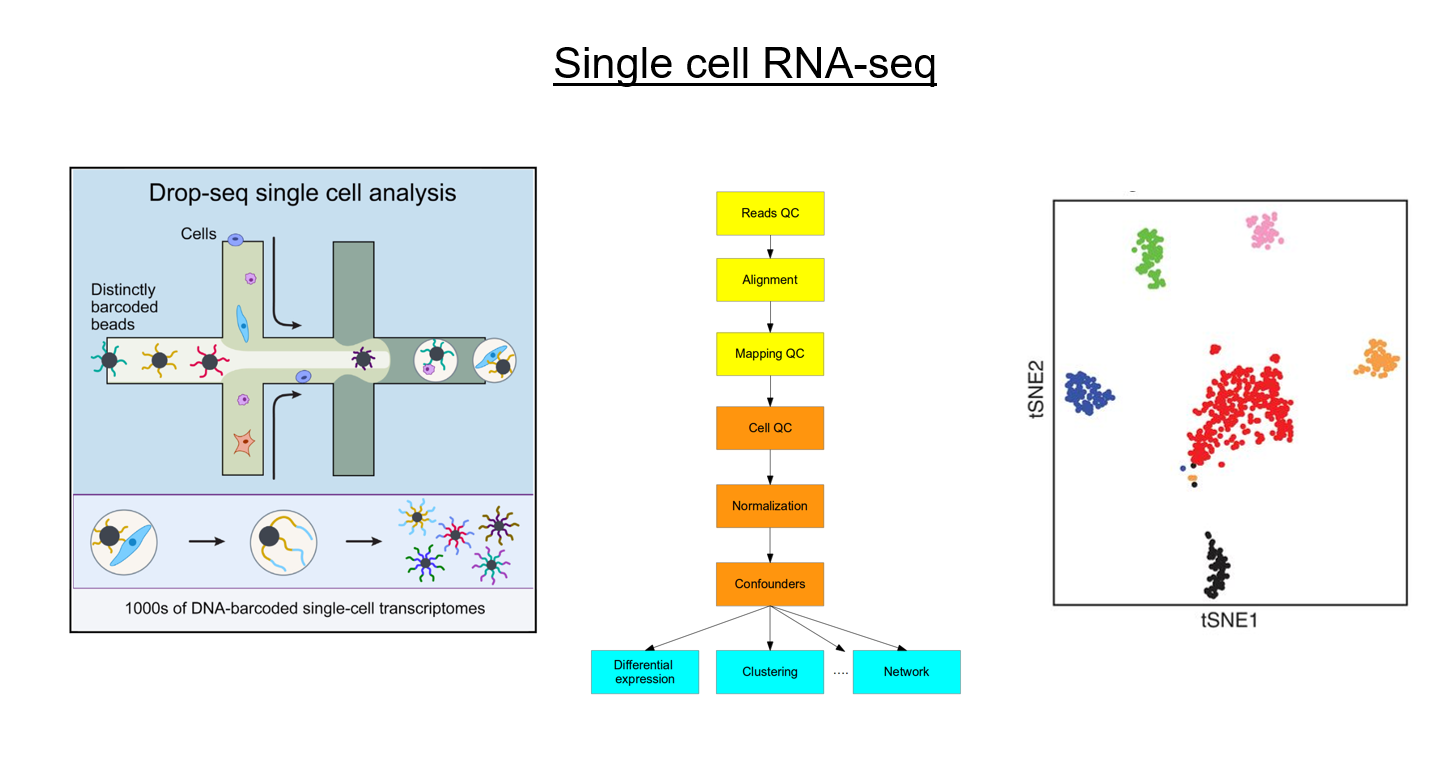

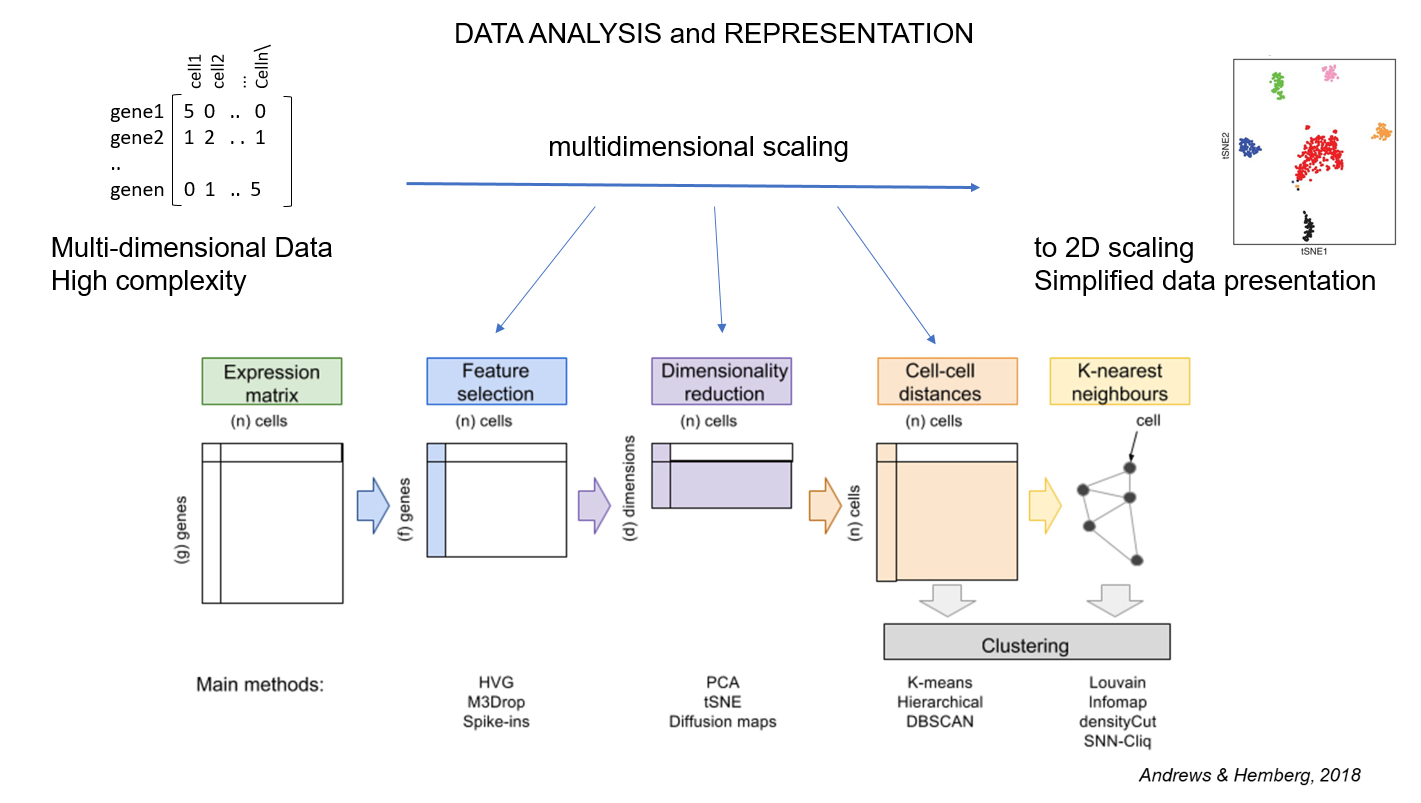

Cellranger output example
http://139.91.75.141/~vtheodorou/web_summary.html

### Configuration block

Keeping all tuneable parameters in one place at the top of the notebook is a good habit.  
It makes the analysis reproducible and lets collaborators adjust thresholds without  
hunting through the code.


In [ ]:
# ── 1.2  Configuration ────────────────────────────────────────────────────────

data_dir <- "/content/drive/MyDrive/scRNAseq_course/data/e18_cortex/filtered_feature_bc_matrix/"
out_dir  <- "/content/drive/MyDrive/scRNAseq_course/output/"
dir.create(out_dir, showWarnings = FALSE)


In [ ]:
# ── 1.3  Load the three CellRanger files ─────────────────────────────

# 1. The sparse count matrix
#    readMM() returns a 'dgTMatrix' — we convert to the faster 'dgCMatrix'
mat <- readMM(file.path(data_dir, "matrix.mtx.gz"))
mat <- as(mat, "CsparseMatrix")

# 2. Features (genes): column 1 = Ensembl ID, column 2 = gene symbol
genes <- read.delim(file.path(data_dir, "features.tsv.gz"),
                    header = FALSE, col.names = c("ensembl", "symbol", "type"))

# 3. Barcodes (cells)
barcodes <- read.delim(file.path(data_dir, "barcodes.tsv.gz"),
                       header = FALSE, col.names = "barcode")

cat("Matrix dimensions (before naming):", dim(mat), "\n")
cat("  Features file rows:", nrow(genes), "\n")
cat("  Barcodes file rows:", nrow(barcodes), "\n")

> **Important:** The matrix has no row or column names yet — it is just numbers.  
> The row order matches the features file, and the column order matches the barcodes file.  
> We assign names next. This is a common source of bugs when files are mismatched.


In [ ]:
# ── 1.4  Assign row and column names ──────────────────────────────────────────

# Gene symbols are not guaranteed to be unique in the mouse genome
# (pseudogenes, multi-mapping loci). make.unique() appends '.1', '.2', etc.
rownames(mat) <- make.unique(genes$symbol)
colnames(mat) <- barcodes$barcode

# Sanity check — peek at the top-left corner of the matrix
cat("Top-left 5x5 of count matrix:\n")
print(mat[1:5, 1:5])
cat("\nMatrix class:", class(mat), "\n")
cat("Memory used by matrix:", format(object.size(mat), units = "MB"), "\n")


In [ ]:
# ── 1.5  Create the Seurat object ─────────────────────────────────────────────
#
# min.cells:    a gene must appear in ≥3 cells to be kept.
#               This removes genes seen in only 1-2 cells — likely noise or sequencing errors.
#               It dramatically reduces matrix size without losing informative genes.
#
# min.features: a barcode must have ≥200 detected genes to be kept.
#               This is a very permissive initial filter — it removes the most obvious
#               empty droplets. We will apply tighter filters later, AFTER inspecting
#               the distribution.

seu <- CreateSeuratObject(
  counts       = mat,
  project      = "E18_Cortex",
  min.cells    = 3,
  min.features = 200
)

seu


**Understanding the Seurat object:**

The Seurat object is a structured container — think of it as a filing cabinet for your  
entire analysis. As we proceed, we will add normalized data, dimensionality reductions,  
cluster labels, and metadata to the same object. This keeps everything synchronized.

Key slots:
- `seu[["RNA"]]@counts` — raw integer counts (never overwritten)
- `seu[["RNA"]]@data` — normalized data (filled after normalization)
- `seu@meta.data` — per-cell metadata (QC metrics, cluster labels, etc.)
- `seu@reductions` — PCA, UMAP embeddings (filled later)

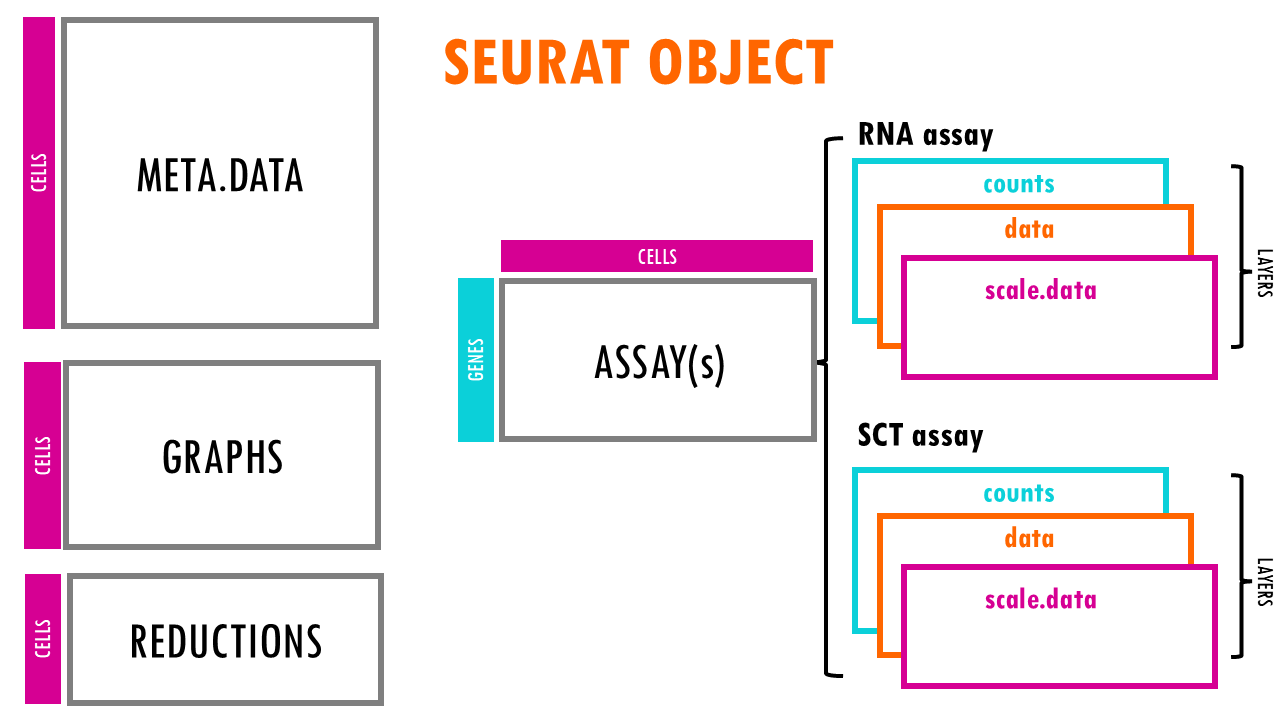

In [ ]:
head(seu@meta.data)

---
## Module 2 — QC Metric Calculation & Pre-Filter Exploration

### The three things that go wrong in a droplet experiment

Droplet-based scRNAseq (10x Chromium) works by encapsulating single cells in oil droplets  
with a barcoded bead. The process is imperfect in three ways:

**1. Empty droplets or debris**  
The droplet captured ambient RNA but no intact cell. These barcodes have very low UMI  
counts and very few detected genes. CellRanger's "filtered" matrix removes the most  
obvious ones, but some borderline cases remain.

**2. Dead or damaged cells**  
A dying cell lyses and loses its cytoplasmic RNA. What remains is disproportionately  
mitochondrial RNA (which is protected inside intact mitochondria). These cells have:  
- High `percent.mt` (the diagnostic signal)
- Low `nCount_RNA` (cytoplasm has emptied)  

We also set a **lower** bound on `percent.mt`. A cell with zero mitochondrial reads is  
biologically implausible — mitochondria are ubiquitous — and likely represents a barcode  
that captured ambient nuclear RNA, not a real cell.

**3. Doublets**  
Two cells co-encapsulated in one droplet. They appear as a single barcode with:  
- Approximately double the expected `nCount_RNA`  
- Approximately double the expected `nFeature_RNA`  
- In UMAP space: often positioned "between" two clusters (the source cell types)

Doublets are the most dangerous artifact because they can be mistaken for transitional  
or rare cell states. We detect them computationally in Module 5.


In [ ]:
# ── 2.1  Calculate QC metrics ─────────────────────────────────────────────────

# Mitochondrial genes: in mouse, these are named 'mt-Nd1', 'mt-Co1', etc.
# The pattern '^mt-' (lowercase, hyphen) is mouse-specific.
# In human it would be '^MT-'; in Drosophila '^mt:' — always check your organism.
seu[["percent.mt"]] <- PercentageFeatureSet(seu, pattern = "^mt-")

# Ribosomal protein genes: 'Rps' (small subunit) and 'Rpl' (large subunit)
seu[["percent.ribo"]] <- PercentageFeatureSet(seu, pattern = "^Rp[sl]")

# Preview the metadata table
head(seu@meta.data, 8)


### Look at distributions BEFORE setting thresholds

This is the most important habit in scRNAseq QC. **Never apply thresholds from a  
previous dataset or from a paper without first inspecting your own data.**  
Thresholds depend on:

- The organism and tissue (neurons have different MT content than hepatocytes)
- The protocol (v2 vs v3 chemistry; fresh vs frozen)
- The sequencing depth
- The biological condition (stressed or damaged tissue will have higher MT content)

The plots below let us see where the real cell population sits, and where the  
dead/empty/doublet tails begin.


In [ ]:
# ── 2.2  Violin plots of QC metrics ───────────────────────────────────────────
# Each dot is a cell. The violin shape shows the density of the distribution.
# pt.size = 0 hides individual points for clarity at this cell number.

VlnPlot(seu,
        features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.ribo"),
        ncol     = 4,
        pt.size  = 0) &
  theme(axis.title.x = element_blank())


In [ ]:
p1 <- FeatureScatter(seu, feature1 = "nCount_RNA", feature2 = "nFeature_RNA") +
  ggtitle("Count vs. genes detected") +
  theme(legend.position = "none")

p2 <- FeatureScatter(seu, feature1 = "nCount_RNA", feature2 = "percent.mt") +
  ggtitle("Count vs. % mitochondrial") +
  theme(legend.position = "none")

p1 | p2

**Reading these plots:**

- **Left plot:** The main cloud of real cells follows a roughly linear relationship  
  (more total reads → more genes detected). Cells far *above* the line have unusually  
  high gene diversity for their read depth — doublets. Cells in the bottom-left corner  
  are empty droplets.

- **Right plot:** Dead/damaged cells cluster in the top-left: high `percent.mt` but  
  low total counts (their cytoplasm has leaked out). The red dashed lines show our  
  planned thresholds — verify they cleanly separate the outlier populations.

- **Lower MT floor:** Notice cells at `percent.mt = 0`. A cell with zero mitochondrial  
  reads is biologically implausible — every real cell has mitochondria. These are  
  likely nuclear fragments or ambient RNA events, not intact cells.


In [ ]:
df_qc <- seu@meta.data

p3 <- ggplot(df_qc, aes(x = nCount_RNA)) +
  geom_density(fill = "steelblue", alpha = 0.4) +
  scale_x_log10() +
  labs(title = "UMI count distribution (log10 scale)",
       x = "nCount_RNA", y = "Density") +
  theme_classic()

p4 <- ggplot(df_qc, aes(x = nFeature_RNA)) +
  geom_density(fill = "darkorchid3", alpha = 0.4) +
  scale_x_log10() +
  labs(title = "Genes detected distribution (log10 scale)",
       x = "nFeature_RNA", y = "Density") +
  theme_classic()

p5 <- ggplot(df_qc, aes(x = percent.mt)) +
  geom_density(fill = "tomato3", alpha = 0.4) +
  labs(title = "Mitochondrial % distribution",
       x = "percent.mt", y = "Density") +
  theme_classic()

(p3 | p4) / p5

> **Threshold-setting principle:** Place thresholds in the *valleys* between  
> distributions, not at arbitrary round numbers. The valley in the `nCount_RNA`  
> density plot separates empty droplets from real cells. Anything above the  
> upper-count shoulder is suspicious for doublets. Your thresholds should feel  
> like they belong to the data, not imported from a paper.


In [ ]:
# Set quality control thresholds
ncount_lower   <- 5000
ncount_upper   <- 50000
nfeature_lower <- 1500
nfeature_upper <- 8000
pct_mt_upper   <- 20
pct_mt_lower   <- 0

In [ ]:
# ── 2.5  How many cells would each threshold remove? ──────────────────────────
# Always quantify before cutting — surprises here indicate a threshold is too aggressive.

cat("Cells before QC filtering:", ncol(seu), "\n\n")

cat("Would be removed by nCount_RNA lower (", ncount_lower, "):",
    sum(seu$nCount_RNA < ncount_lower), "\n")
cat("Would be removed by nCount_RNA upper (", ncount_upper, "):",
    sum(seu$nCount_RNA > ncount_upper), "\n")
cat("Would be removed by nFeature_RNA lower (", nfeature_lower, "):",
    sum(seu$nFeature_RNA < nfeature_lower), "\n")
cat("Would be removed by nFeature_RNA upper (", nfeature_upper, "):",
    sum(seu$nFeature_RNA > nfeature_upper), "\n")
cat("Would be removed by percent.mt upper (", pct_mt_upper, "):",
    sum(seu$percent.mt > pct_mt_upper), "\n")
cat("Would be removed by percent.mt lower (", pct_mt_lower, "):",
    sum(seu$percent.mt < pct_mt_lower), "\n")


---
## Module 3 — Initial SCTransform & Unfiltered UMAP

### Why run a UMAP *before* filtering?

Running dimensionality reduction on unfiltered data lets you:

1. **See where the problematic cells sit** — doublets often appear as "bridge" clusters  
   between two real populations; dead cells often form their own isolated cluster
2. **Validate your QC thresholds** — does `percent.mt` track onto specific regions of  
   the UMAP, or is it diffuse?
3. **Detect unexpected structure** — if your data has batch effects or unexpected  
   cell types, you'll see them here, before you've committed to filtering decisions


### SCTransform — why not LogNormalize?

The standard `NormalizeData()` approach divides each cell by its total counts, scales,  
and log-transforms. This works but has a known problem: highly expressed genes  
contribute disproportionately to downstream PCA, even after scaling.

**SCTransform** (Hafemeister & Satija, *Genome Biology*, 2019) instead:
1. Fits a **regularized negative binomial regression** for each gene, modeling counts  
   as a function of sequencing depth
2. Takes the **Pearson residuals** — what's left after removing the effect of library size
3. These residuals are approximately mean-zero, variance-stabilized, and ready for PCA  
   without a separate scaling step

The practical result: SCTransform is more robust to highly expressed genes and  
typically produces cleaner separation of cell types in PCA.


In [ ]:
# ── 3.1  SCTransform on unfiltered data ───────────────────────────────────────
#
# vst.flavor = "v2" uses glmGamPoi for speed and the refined residual formula.
# return.only.var.genes = FALSE keeps all genes in the SCT assay, not just HVGs —
#   important if you want to visualize non-variable genes later.
# conserve.memory = TRUE avoids storing large intermediate matrices.

seu <- SCTransform(seu,
                   vst.flavor          = "v2",
                   return.only.var.genes = FALSE,
                   conserve.memory     = TRUE,
                   verbose             = FALSE)

cat("Variable features selected by SCTransform:", length(VariableFeatures(seu)), "\n")
cat("Active assay after SCTransform:", DefaultAssay(seu), "\n")


In [ ]:
# ── 3.2  PCA ──────────────────────────────────────────────────────────────────
seu <- RunPCA(seu, npcs = 50, verbose = FALSE)

ElbowPlot(seu, ndims = 30)


**Reading the elbow plot:**

Each point is a principal component. The y-axis is the standard deviation of that  
component — how much variance it captures. We want to include PCs that capture real  
biological signal and exclude PCs that are predominantly noise.

The "elbow" is the inflection point where the curve flattens. Including PCs beyond  
the elbow adds noise without adding signal. We will revisit this decision on the  
filtered data in Module 8.

> **There is no objectively correct answer here.** The elbow is sometimes ambiguous.  
> A practical approach: choose a value, proceed, and check whether changing it by  
> ±5 PCs substantially alters your clusters. If not, your downstream results are robust.


In [ ]:
# ── 3.3  UMAP and initial clustering on unfiltered data ───────────────────────
seu <- RunUMAP(seu, dims = 1:16, verbose = FALSE)
seu <- FindNeighbors(seu, dims = 1:16, verbose = FALSE)
seu <- FindClusters(seu, resolution = 1, verbose = FALSE)

DimPlot(seu, reduction = "umap", label = TRUE, label.size = 4) +
  ggtitle("UMAP — unfiltered (before QC)") +
  theme(legend.position = "none")


In [ ]:
# ── 3.4  Overlay QC metrics on the unfiltered UMAP ────────────────────────────
# This is the diagnostic payoff. We want to see whether QC metrics are localized
# (concentrated in specific clusters = those clusters are probably artifacts)
# or diffuse (spread across all clusters = harder to filter by cluster identity).

p_mt   <- FeaturePlot(seu, features = "percent.mt", order = TRUE, max.cutoff = "q99") +
           scale_color_viridis_c(option = "inferno") +
           ggtitle("% mitochondrial")

p_feat <- FeaturePlot(seu, features = "nFeature_RNA", order = TRUE, max.cutoff = "q99") +
           scale_color_viridis_c(option = "viridis") +
           ggtitle("Genes detected (nFeature)")

p_umi  <- FeaturePlot(seu, features = "nCount_RNA", order = TRUE, max.cutoff = "q99") +
           scale_color_viridis_c(option = "magma") +
           ggtitle("UMI count (nCount)")

p_ribo <- FeaturePlot(seu, features = "percent.ribo", order = TRUE, max.cutoff = "q99") +
           scale_color_viridis_c(option = "cividis") +
           ggtitle("% ribosomal")

(p_mt | p_feat) / (p_umi | p_ribo)


**What to look for:**

- Any cluster dominated by high `percent.mt` and low `nFeature_RNA` is likely  
  dead/damaged cells and should disappear cleanly after our filters
- Clusters with anomalously high `nCount_RNA` and `nFeature_RNA` relative to  
  their neighbors are doublet-enriched — we will catch these with scDblFinder
- A cluster with uniformly low `nFeature_RNA` (but not high MT) may be a  
  real cell type with naturally simple transcriptomes (e.g., red blood cells)  
  — don't filter it without investigation


---
## Module 4 — Cell Cycle Scoring

### Why score cell cycle?

Actively dividing cells express a large, coordinated set of genes related to DNA  
replication (S phase) and mitosis (G2/M phase). In tissues with proliferating cells —  
like an E18 cortex, where progenitors are still dividing — this transcriptional  
program can drive major axes of variation in PCA.

**The consequence:** Without addressing cell cycle, your clusters may reflect  
"dividing vs. non-dividing" rather than "cell type A vs. cell type B". Progenitors  
in S phase and progenitors in G1 might form two separate clusters that look like  
distinct cell types but are actually the same cell type at different cell cycle stages.

**The decision:** Regress out cell cycle, or not? This is a genuine biological choice:

| Situation | Recommendation |
|-----------|---------------|
| Cell cycle is a nuisance (you care about cell type, not phase) | Regress it out |
| Cell cycle *is* the biology (studying proliferation, cancer) | Do NOT regress |
| Unsure | Score it, visualize it, then decide |

We always score first and decide second.


In [ ]:
# ── 4.1  Cell cycle scoring ───────────────────────────────────────────────────
# Seurat ships with human cell cycle gene lists (cc.genes.updated.2019).

# For other organisms you may need an organism-specific list.

# Pre-defined mouse orthologs for S-phase and G2M-phase genes
# (Derived from https://github.com/satijalab/seurat/blob/master/data/cell_cycle_genes.R)

s_genes <- c("Mcm5", "Pcna", "Tyms", "Fen1", "Mcm7", "Mcm4", "Rrm1", "Ung", "Gins2", "Mcm6", "Cdc6", "Exo1", "Tipin", "Blm", "Pold3", "Msh2", "Pola1", "Rfc2", "Uhrf1", "Rrm2", "Rad51", "Cdc45", "Sclp", "Hells", "Mcm2", "Mcm3", "Mcm10", "Dtl", "Atad2", "Cdc7", "Cdc25a", "Ccnb1", "Ccnb2", "Ccne1", "Ccne2", "Cdk1", "Cdk2", "Cdk4", "Cdkn1a", "Cdkn1b", "Pcna", "Topbp1")
g2m_genes <- c("Hmgb2", "Cdk1", "Nusap1", "Ube2c", "Birc5", "Tpx2", "Top2a", "Ndc80", "Cks2", "Nuf2", "Cks1b", "Mki67", "Tmpo", "Cenpf", "Tacc3", "Pimreg", "Smc4", "Ccnb2", "Ckap2l", "Ckap2", "Aurkb", "Bub1", "Kif11", "Anp32e", "Tubb4b", "Gtse1", "Kif20b", "Hjurp", "Cdca3", "Jpt1", "Cdc20", "Ttk", "Cdc25c", "Kif2c", "Rangap1", "Ncapd2", "Dlgap5", "Cdca2", "Cdca8", "Ect2", "Kif23", "Hmmr", "Aurka", "Psrc1", "Anln", "Lbr", "Ckap5", "Cenpe", "Ctcf", "Nek2", "G2e3", "Gas2l3", "Cbx5", "Cenpa")

In [ ]:
# CellCycleScoring adds S.Score and G2M.Score to meta.data, and assigns
# each cell to a phase: S, G2M, or G1 (residual = not clearly in S or G2M).
# Note: this function requires normalized data — it uses the SCT assay here.

seu <- CellCycleScoring(seu,
                        s.features   = s_genes,
                        g2m.features = g2m_genes,
                        set.ident    = FALSE)  # don't replace cluster identity

head(seu@meta.data[, c("S.Score", "G2M.Score", "Phase")], 8)


In [ ]:
# ── 4.2  Visualise cell cycle on the unfiltered UMAP ─────────────────────────

p_phase  <- DimPlot(seu, group.by = "Phase", cols = c("G1" = "grey80",
                                                       "S"  = "#2166ac",
                                                       "G2M"= "#d6604d")) +
             ggtitle("Cell cycle phase")

p_sscore <- FeaturePlot(seu, features = "S.Score", order = TRUE) +
             scale_color_gradient2(low = "grey90", mid = "white", high = "#2166ac") +
             ggtitle("S phase score")

p_g2m    <- FeaturePlot(seu, features = "G2M.Score", order = TRUE) +
             scale_color_gradient2(low = "grey90", mid = "white", high = "#d6604d") +
             ggtitle("G2M phase score")

p_phase
p_sscore
p_g2m


**Interpreting these plots:**

In the E18 cortex, you should see cycling cells (S and G2M) concentrated in specific  
regions of the UMAP — these correspond to the progenitor populations (radial glia and  
intermediate progenitors). Neurons are post-mitotic and should be overwhelmingly G1.

This localization tells us two things:
1. Cell cycle is not a random nuisance — it correlates with a real biological property (cell type)
2. If we regress cell cycle scores, we are partially collapsing the progenitor population  
   into the differentiated population — potentially losing resolution we care about

**For this dataset**, we will regress cell cycle scores in Module 7 to give a clean view  
of cell types. But this is a pedagogical choice, not the only correct answer.


---
## Module 5 — Doublet Detection with scDblFinder

### The doublet problem

In 10x Chromium experiments, the rate of doublets scales with cell loading density.  
At typical loading densities, 5–10% of recovered barcodes are doublets.

**Why are doublets dangerous?**  
A doublet combines the transcriptomes of two real cells. In a UMAP embedding, doublets  
tend to appear:
- Between two clusters (the two source cell types)
- As spurious rare cell populations
- As artificial "transition" states if the source cells are developmentally related

Automated doublet detection works by **simulation**: the algorithm artificially creates  
synthetic doublets by mixing pairs of real cells, then trains a classifier to distinguish  
real singlets from these synthetic doublets (and real doublets, which look similar to them).

**scDblFinder** (Germain et al., *F1000Research*, 2021) is currently the best-performing  
doublet detector by benchmarking. It is faster and more accurate than DoubletFinder.

### Critical implementation detail: run per sample, not on the merged object

Doublets are formed *within* each sample during encapsulation. A "doublet" that crosses  
samples is biologically impossible with current technology. If you run doublet detection  
on a merged multi-sample object, the algorithm will simulate inter-sample doublets, which  
do not exist, inflating false positives in cells that are simply rare or boundary cell types.

**Always run doublet detection per sample, then transfer labels to the merged object.**

In this single-sample dataset we have one sample, so this is moot — but the code below  
is structured the way a multi-sample workflow would be.


In [ ]:
# ── 5.1  Doublet detection ────────────────────────────────────────────────────
# scDblFinder works on a SingleCellExperiment object.
# We convert from Seurat, run the detector, then transfer the labels back.

library(SingleCellExperiment)

sce <- as.SingleCellExperiment(seu, assay = "RNA")

# scDblFinder parameters:
#   clusters = TRUE: use cluster structure to improve doublet simulation
#               (better than NULL for structured data like brain)
#   BPPARAM: parallelization — use SerialParam() for single-threaded (safer for teaching)

set.seed(42)
sce_dbl <- scDblFinder(sce,
                       clusters = TRUE,
                       BPPARAM  = BiocParallel::SerialParam())

# Transfer doublet labels and scores back to Seurat metadata
seu$scDblFinder.class <- sce_dbl$scDblFinder.class
seu$scDblFinder.score <- sce_dbl$scDblFinder.score

cat("Doublet calls:\n")
print(table(seu$scDblFinder.class))
cat("\nDoublet rate:", round(mean(seu$scDblFinder.class == "doublet") * 100, 1), "%\n")


In [ ]:
# ── 5.2  Where do doublets sit in the UMAP? ───────────────────────────────────

p_dbl_class <- DimPlot(seu,
                        group.by = "scDblFinder.class",
                        cols     = c("singlet" = "grey85", "doublet" = "firebrick")) +
               ggtitle("scDblFinder classification")

p_dbl_score <- FeaturePlot(seu,
                            features = "scDblFinder.score",
                            order    = TRUE,
                            max.cutoff = "q99") +
               scale_color_gradientn(colours = c("grey90", "orange", "firebrick")) +
               ggtitle("Doublet score (continuous)")

p_dbl_class | p_dbl_score


**Interpreting doublet positions:**

Predicted doublets concentrated at cluster boundaries are the expected pattern — these are  
barcodes that captured two cells from adjacent populations. If doublets are scattered  
randomly throughout all clusters, it may indicate the classifier is uncertain (perhaps  
because the dataset lacks clear cluster structure at this stage). In that case, the  
continuous score is more informative than the binary class.

We do not remove doublets yet — we will do so together with the other QC filters in Module 6.


---
## Module 6 — Applying QC Filters & Removing Uninformative Features

### Filtering cells

We now apply all thresholds simultaneously. Removing cells one filter at a time can  
remove cells that would have passed a joint filter — for example, a cell near the MT  
threshold but well within nFeature bounds. The joint filter is more biologically principled.


In [ ]:
# ── 6.1  Record pre-filter counts ─────────────────────────────────────────────
n_before <- ncol(seu)
cat("Cells before filtering:", n_before, "\n\n")

# Which cells pass each individual threshold?
pass_ncount_lo  <- seu$nCount_RNA   > ncount_lower
pass_ncount_hi  <- seu$nCount_RNA   < ncount_upper
pass_nfeat_lo   <- seu$nFeature_RNA > nfeature_lower
pass_nfeat_hi   <- seu$nFeature_RNA < nfeature_upper
pass_mt_hi      <- seu$percent.mt   < pct_mt_upper
pass_mt_lo      <- seu$percent.mt   > pct_mt_lower
pass_singlet    <- seu$scDblFinder.class == "singlet"

# Summary table — helps spot if one threshold is unexpectedly aggressive
filter_summary <- data.frame(
  Filter   = c("nCount > lower", "nCount < upper", "nFeature > lower",
               "nFeature < upper", "MT < upper", "MT > lower", "Singlet"),
  Passing  = c(sum(pass_ncount_lo), sum(pass_ncount_hi), sum(pass_nfeat_lo),
               sum(pass_nfeat_hi),  sum(pass_mt_hi),     sum(pass_mt_lo),
               sum(pass_singlet)),
  Removed  = c(sum(!pass_ncount_lo), sum(!pass_ncount_hi), sum(!pass_nfeat_lo),
               sum(!pass_nfeat_hi),  sum(!pass_mt_hi),     sum(!pass_mt_lo),
               sum(!pass_singlet))
)
print(filter_summary)


In [ ]:
# ── 6.2  Apply all filters jointly ────────────────────────────────────────────
cells_keep <- colnames(seu)[
  pass_ncount_lo & pass_ncount_hi &
  pass_nfeat_lo  & pass_nfeat_hi  &
  pass_mt_hi     & pass_mt_lo     &
  pass_singlet
]

seu <- subset(seu, cells = cells_keep)

n_after <- ncol(seu)
cat("Cells after all QC filters:", n_after, "\n")
cat("Cells removed:", n_before - n_after,
    sprintf("(%.1f%%)", (n_before - n_after) / n_before * 100), "\n")


### Removing uninformative features (genes)

Beyond filtering cells, we also remove specific gene categories from the feature set.  
These genes can dominate the PCA and pull cells apart based on technical or non-cell-type  
signals rather than actual transcriptional identity.

**Ribosomal protein genes (`Rps*`, `Rpl*`):**  
Ribosomal protein gene expression varies substantially between cells, but this variation  
reflects the general translational activity of the cell, not its identity. A neuron with  
high ribosomal gene expression is still a neuron. Including these genes means your PCA  
will partly separate "high translation" from "low translation" cells — rarely the signal  
you want as the dominant axis.

> **Note:** There is genuine debate here. Some workflows keep ribosomal genes. The key  
> question is: does removing them change your biological conclusions? Check both ways.


In [ ]:
# ── 6.3  Remove ribosomal protein genes ───────────────────────────────────────
genes_before <- nrow(seu)

ribo_genes   <- grep("^Rp[sl]", rownames(seu), value = TRUE)
genes_to_keep <- setdiff(rownames(seu), ribo_genes)

cat("Ribosomal genes to remove:", length(ribo_genes), "\n")
cat("Example ribosomal genes:", paste(head(ribo_genes, 5), collapse = ", "), "\n\n")

# Subset the Seurat object to keep only the desired genes
# We use the RNA assay as the base — SCT will be re-run fresh in Module 7
DefaultAssay(seu) <- "RNA"
seu <- seu[genes_to_keep, ]

cat("Genes before removal:", genes_before, "\n")
cat("Genes after removal: ", nrow(seu), "\n")


In [ ]:
# ── 6.4  QC violin plots post-filtering — confirm the filters worked ───────────
Idents(seu) <- seu$orig.ident
VlnPlot(seu,
        features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
        ncol     = 3,
        pt.size  = 0) &
  theme(axis.title.x = element_blank())


---
## Module 7 — Final SCTransform with Confounder Regression

### What are we regressing and why?

After filtering, we re-run SCTransform — this time on the clean data, and with  
`vars.to.regress` to remove sources of variation we do not want driving our clusters.

We regress:
- **`S.Score` and `G2M.Score`:** Removes cell cycle as a driver of PCA. Progenitors  
  in S phase and G1 will now cluster together, revealing their shared cell-type identity  
  rather than their cycling status.
- **`percent.mt`:** Even after filtering out high-MT cells, there is still a continuous  
  gradient of mitochondrial content among the remaining cells. Regressing this removes  
  residual stress-related variation.

**Mechanistically:** SCTransform fits a regression model that includes these covariates.  
The Pearson residuals — the input to PCA — are then the variation that *cannot* be  
explained by library size or the regressed covariates. Only the unexplained, residual  
variation enters the PCA.


In [ ]:
# ── 7.1  SCTransform with regression ─────────────────────────────────────────
# This replaces the SCT assay from Module 3.
# It will take a minute — SCTransform fits a model per gene.

seu <- SCTransform(seu,
                   vst.flavor          = "v2",
                   vars.to.regress     = c("S.Score", "G2M.Score"),
                   return.only.var.genes = FALSE,
                   conserve.memory     = TRUE,
                   verbose             = FALSE)

cat("SCTransform complete.\n")
cat("Variable features:", length(VariableFeatures(seu)), "\n")
cat("Active assay:", DefaultAssay(seu), "\n")


In [ ]:
# ── 7.2  PCA on filtered, regressed data ─────────────────────────────────────
seu <- RunPCA(seu, npcs = 50, verbose = FALSE)

ElbowPlot(seu, ndims = 30)


---
## Module 8 — UMAP & Graph-Based Clustering

### Graph-based clustering: the logic

Seurat uses a **KNN → SNN → Louvain/Leiden** pipeline:

1. **K-nearest neighbor (KNN) graph:** In PCA space, find the K most similar cells  
   for each cell. Connect them with edges. We now have a graph where nodes = cells  
   and edges = similarity.

2. **Shared nearest neighbor (SNN) refinement:** The weight of each edge is rescaled  
   by how many neighbors the two cells *share*. Two cells that share many neighbors  
   are almost certainly in the same real population; their edge is strengthened.  
   Edges between cells that share few neighbors are pruned. This makes the graph  
   more robust to outliers and local density variation.

3. **Community detection (Louvain or Leiden):** The graph is partitioned into  
   "communities" — groups of nodes that are more densely connected to each other  
   than to the rest of the graph. This is called maximizing **modularity**.

Why is this better than k-means for scRNAseq?  
- k-means assumes spherical clusters of equal size — rare in scRNAseq  
- Graph methods find clusters of arbitrary shape and size  
- They naturally handle the "horseshoe" or trajectory structures common in developmental data


In [ ]:
# ── 8.1  Build neighbor graph and run UMAP ────────────────────────────────────
seu <- FindNeighbors(seu,
                     dims    = 1:16,     # Number of PCA components to use
                     k.param = 20,       # K for KNN graph — default 20 is usually fine
                     verbose = FALSE)


In [ ]:
# ── 9.4  Side-by-side UMAPs at different PCA dimensions ──────────────────────
# This visualizes how the number of PCs used for UMAP affects the embedding.
# The 'dims' parameter in RunUMAP determines how many PCs are used.
dims_to_plot <- c(5, 10, 16, 25) # Vary number of dimensions

umap_dims_list <- lapply(dims_to_plot, function(n_dims) {
  # Run UMAP with the specified number of dimensions
  temp_seu <- RunUMAP(seu, dims = 1:n_dims, verbose = FALSE, seed.use = 42)
  DimPlot(temp_seu, reduction = "umap", label = FALSE) + # No labels for clarity
    ggtitle(paste0("UMAP (dims = ", n_dims, ")")) +
    theme(legend.position = "none")
})

(umap_dims_list[[1]] | umap_dims_list[[2]]) / (umap_dims_list[[3]] | umap_dims_list[[4]])

In [ ]:
res_to_plot <- c(0.2, 0.6, 1.0, 1.5)

umap_list <- lapply(res_to_plot, function(res) {
  # Run FindClusters for the current resolution
  seu <- FindClusters(seu, resolution = res, verbose = FALSE)
  col_name  <- paste0("SCT_snn_res.", res)
  n_clust   <- length(unique(seu@meta.data[[col_name]]))
  DimPlot(seu, group.by = col_name, label = TRUE, label.size = 3) +
    ggtitle(paste0("res = ", res, " (", n_clust, " clusters)")) +
    theme(legend.position = "none")
})

(umap_list[[1]] | umap_list[[2]]) / (umap_list[[3]] | umap_list[[4]])

In [ ]:
# ── 8.2  Find clusters at chosen umap dimensions and resolution ───────────────────────────────────
# UMAP uses the same PCA dims as the neighbor graph
# For reproducibility, always set seed.use
seu <- RunUMAP(seu, dims = 1:16,   # Number of PCA components to use
                verbose = FALSE)

seu <- FindClusters(seu,
                    resolution = 1,
                    verbose    = FALSE)

print(table(seu$seurat_clusters))


In [ ]:
# ── 8.3  UMAP plots — by cluster and by cell cycle ────────────────────────────
p_clust <- DimPlot(seu, reduction = "umap", label = TRUE, label.size = 5) +
           ggtitle(paste0("Clusters ")) +
           theme(legend.position = "none")

p_phase <- DimPlot(seu, group.by = "Phase",
                   cols = c("G1" = "grey80", "S" = "#2166ac", "G2M" = "#d6604d")) +
           ggtitle("Cell cycle phase (after regression)")

p_clust | p_phase


---
## Module 10 — Marker Gene Identification

### What makes a good marker gene?

A marker gene for a cluster should be:

1. **Expressed in a high fraction of cells in the target cluster** (`pct.1` high)
2. **Not expressed (or expressed at much lower levels) in other clusters** (`pct.2` low)
3. **Statistically significant** (low adjusted p-value after multiple testing correction)
4. **Biologically coherent** — ideally consistent with known biology for the expected cell type

### The Wilcoxon rank-sum test

Seurat's default test for marker genes is the **Wilcoxon rank-sum test** (also called  
the Mann-Whitney U test). For each gene and each cluster, it asks:

> Are the normalized expression values in cells from this cluster *systematically higher*  
> than in cells from all other clusters?

It does this by ranking all expression values and testing whether the ranks in one group  
tend to exceed the ranks in another — no assumptions about the distribution of counts.

**Why not a t-test or DESeq2?**

- t-tests assume normality — scRNAseq counts are far from normal (zero-inflated, skewed)
- DESeq2 is designed for bulk RNA-seq (pseudoreplication concerns apply to single cells)
- The Wilcoxon test is conservative and well-calibrated for scRNAseq, and has been  
  shown to perform well in systematic benchmarks (Squair et al., *Nature Methods*, 2021)

**`avg_log2FC` vs. p-value:**  
In datasets with many cells, nearly every gene will be statistically significant.  
Sort by `avg_log2FC` first — a gene with p-value = 1e-200 and log2FC = 0.1 is  
technically significant but biologically uninformative. A gene with log2FC = 3  
that is expressed in 80% of target cells is a useful marker.


In [ ]:
# ── 10.1  PrepSCTFindMarkers — required before FindAllMarkers on SCT ──────────
# SCTransform fits per-cell scaling factors. Before differential expression,
# we need to revert to a common model. This step ensures fair comparison.
# (Only needed with SCT assay; not required for LogNormalize.)

DefaultAssay(seu) <- "SCT"
Idents(seu)       <- "seurat_clusters"

seu <- PrepSCTFindMarkers(seu, verbose = FALSE)


In [ ]:
# ── 10.2  Find all markers ────────────────────────────────────────────────────
# only.pos = TRUE: we only want genes ENRICHED in the cluster (positive markers).
#   Negative markers (genes repressed in a cluster) are harder to interpret
#   and less useful for annotation.
# min.pct = 0.2: the gene must be detected in at least 20% of cells in EITHER
#   the cluster or the rest. This speeds up computation by skipping rarely expressed genes.
# logfc.threshold = 0.5: require at least 2^0.5 ≈ 1.4x fold-change. This skips
#   genes with trivially small differences.

options(future.globals.maxSize = 4 * 1024^3)  # 4 GB memory

all_markers <- FindAllMarkers(seu,
                              only.pos        = TRUE,
                              min.pct         = 0.2,
                              logfc.threshold = 0.5,
                              test.use        = "wilcox",
                              verbose         = FALSE)

cat("Total marker genes found:", nrow(all_markers), "\n")
cat("\nColumn descriptions:\n")
cat("  p_val      : raw Wilcoxon p-value\n")
cat("  avg_log2FC : average log2 fold-change (cluster vs. all others)\n")
cat("  pct.1      : fraction of cells IN cluster expressing the gene\n")
cat("  pct.2      : fraction of cells OUTSIDE cluster expressing the gene\n")
cat("  p_val_adj  : Bonferroni-corrected p-value — USE THIS for significance\n")

head(all_markers, 10)


In [ ]:
# ── 10.3  Top 10 markers per cluster sorted by fold-change ─────────────────────
top10 <- all_markers %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = 10) %>%
  ungroup()

# Save to file
write.csv(all_markers, file.path(out_dir, "all_markers.csv"), row.names = FALSE)
write.csv(top10,        file.path(out_dir, "top10_markers.csv"), row.names = FALSE)

# Display
top10 %>% dplyr::select(cluster, gene, avg_log2FC, pct.1, pct.2, p_val_adj)

In [ ]:
# ── 10.4  Heatmap of top 10 markers per cluster ────────────────────────────────
# Each column = one cell (grouped by cluster, randomly downsampled for speed)
# Each row = a marker gene
# Colour = scaled expression level
pdf(paste0(out_dir,"heatmap.pdf"))
DoHeatmap(seu,
          features = top10$gene,
          size     = 3,
          angle    = 0) +
  NoLegend() +
  theme(axis.text.y = element_text(size = 7)) +
  ggtitle("Top 5 marker genes per cluster")
dev.off()


In [ ]:
# ── 10.5  Dot plot — the most information-dense summary visualization ──────────
# Dot SIZE  = % of cells in the cluster expressing the gene (pct.1 equivalent)
# Dot COLOR = average scaled expression level
#
# This single plot shows: which genes are specific (small pct in other clusters),
# how strongly they are expressed, and whether any clusters share markers.

options(repr.plot.width = 8, repr.plot.height = 4)
pdf(paste0(out_dir,"dotplot.pdf"), height=10, width=20)
DotPlot(seu,
        features = unique(top10$gene),
        dot.scale = 5,
        cols      = c("lightgrey", "firebrick")) +
  RotatedAxis() +
  theme(axis.text.x = element_text(size = 7),
        axis.text.y = element_text(size = 9)) +
  ggtitle("Top 10 markers per cluster — dot plot")
dev.off()


In [ ]:
# ── 10.6  Feature plots for canonical cortical markers ────────────────────────
# Overlay expression of known marker genes onto the UMAP.
# These let us validate that the clusters correspond to expected cell types.

canonical <- c(
  "Nes",     # radial glia / neural stem cells
  "Pax6",    # radial glia
  "Eomes",   # intermediate progenitors (Tbr2)
  "Neurod2", # immature excitatory neurons
  "Bcl11b",  # deep-layer neurons (Ctip2)
  "Cux1",    # upper-layer neurons
  "Gad1",    # interneurons (GABAergic)
  "Cldn5"    # endothelial cells
)

p<-FeaturePlot(seu,
            features   = canonical,
            ncol       = 4,
            order      = TRUE,
            min.cutoff = "q10") &
  scale_color_gradientn(colours = c("grey92", "#2166ac", "#053061"))

p


In [ ]:
pdf(paste0(out_dir, "markers.pdf"), height=10, width=20)
p
dev.off()

In [ ]:
# ── 10.7  Violin plots for top markers in select clusters ─────────────────────
# Violin plots show the *distribution* of expression, not just the mean.
# This is important: a high average can come from many cells with moderate expression
# OR from a few cells with very high expression. The violin distinguishes these.

VlnPlot(seu,
        features = c("Nes", "Pax6", "Eomes", "Neurod2", "Bcl11b", "Gad1"),
        ncol     = 3,
        pt.size  = 0) &
  theme(axis.text.x = element_text(size = 8, angle = 45, hjust = 1))


In [ ]:
# ── 11.2  Annotation ─────────────────────────────────────────────────────
# EDIT THIS BLOCK after inspecting the heatmap, dotplot, and marker table.
#
# Format: a named vector where:
#   NAMES  = existing cluster numbers (as character)
#   VALUES = new label to assign (can be a number to merge, or a cell type name)
#
# Example: if clusters 2 and 4 have nearly identical markers, map both to "2".
# Clusters you are happy with keep their original number.
#
# The labels below are PLACEHOLDERS — replace with your own after inspection.

new_labels <- c(
  "0" = "Excitatory neuron — deep",
  "1" = "Excitatory neuron — deep",   # <-- merge with 0 if markers overlap
  "2" = "Radial glia",
  "3" = "Excitatory neuron — upper",
  "4" = "Intermediate progenitor",
  "5" = "Excitatory neuron — upper",  # <-- merge with 3 if markers overlap
  "6" = "Interneuron",
  "7" = "Endothelial / VLMC"
  # Add more entries if your resolution produced more clusters
)

# Only rename clusters that exist in the object
existing_clusters <- levels(seu$seurat_clusters)
new_labels <- new_labels[names(new_labels) %in% existing_clusters]

seu <- RenameIdents(seu, new_labels)
seu$cell_type <- Idents(seu)

cat("Cell type assignments:\n")
print(table(seu$cell_type))


In [ ]:
# ── 11.3  Final annotated UMAP ────────────────────────────────────────────────
DimPlot(seu,
        group.by   = "cell_type",
        label      = TRUE,
        label.size = 4,
        repel      = TRUE) +
  ggtitle("E18 Mouse Cortex — annotated cell types") +
  theme(legend.position = "right",
        legend.text = element_text(size = 9))


In [ ]:
# ── 11.4  Final marker dotplot using cell type labels ─────────────────────────
# A clean summary figure — the kind you would include in a paper or report.

final_markers <- c(
  "Nes", "Pax6",         # Radial glia
  "Eomes",               # Intermediate progenitors
  "Neurod2", "Tbr1",     # Immature excitatory neurons
  "Bcl11b", "Fezf2",    # Deep layer excitatory neurons
  "Cux1", "Cux2",        # Upper layer excitatory neurons
  "Gad1", "Dlx2",        # Interneurons
  "Cldn5"                # Endothelial
)

DotPlot(seu,
        features  = final_markers,
        group.by  = "cell_type",
        dot.scale = 6,
        cols      = c("lightgrey", "#08306b")) +
  RotatedAxis() +
  theme(axis.text.x = element_text(size = 10),
        axis.text.y = element_text(size = 10)) +
  ggtitle("Canonical marker genes by annotated cell type")


---
## Module 12 — Saving Outputs


In [ ]:
# ── 12.1  Save the final Seurat object ───────────────────────────────────────
saveRDS(seu, file.path(out_dir, "e18_cortex_final.rds"))
# To reload in a future session:
# seu <- readRDS("output/e18_cortex_final.rds")

# Save marker gene tables
write.csv(all_markers, file.path(out_dir, "all_markers.csv"), row.names = FALSE)
write.csv(top5,        file.path(out_dir, "top5_markers.csv"), row.names = FALSE)

cat("Outputs written to:", out_dir, "\n")
cat("  - e18_cortex_final.rds\n")
cat("  - all_markers.csv\n")
cat("  - top5_markers.csv\n")


---
## Summary: Decision Points in This Workflow

Every step in this workflow involves choices. The table below summarises the key  
decisions and the questions you should ask when applying this to new data.

| Step | Decision | Question to ask |
|------|----------|-----------------|
| QC thresholds | `ncount_lower`, `nfeature_lower` | Where is the valley in the density plot? |
| QC thresholds | `pct_mt_upper` | What is the shape of the MT distribution for this tissue? |
| MT lower bound | `pct_mt_lower` | Are cells with zero MT reads biologically plausible here? |
| Feature removal | Remove ribosomal genes? | Does ribosomal content drive an unwanted axis in PCA? |
| SCTransform | `vars.to.regress` | Is cell cycle variation signal or noise in my question? |
| PCA dims | `dims_use` | Where is the elbow? Is the result robust to ±5 PCs? |
| Resolution | `resolution` | Do the clusters have distinct, interpretable marker genes? |
| Cluster merging | Which clusters to merge? | Are top marker genes essentially identical? |
| Marker test | `logfc.threshold`, `min.pct` | Am I being stringent enough to find truly specific markers? |

---

## Session Information


In [ ]:
sessionInfo()
